In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn lightgbm shap

Note: you may need to restart the kernel to use updated packages.


# Predicción de cancelación de reservas hoteleras

## Contexto de negocio
El equipo de Revenue Management de una cadena con dos hoteles en Portugal (City Hotel y Resort Hotel) necesita identificar, **en el momento de la reserva**, qué reservas tienen alta probabilidad de cancelarse.

Con esa predicción podrá activar acciones preventivas:
- Ofrecer upgrades con descuento.
- Solicitar depósito no reembolsable de forma selectiva.
- Ajustar la política de overbooking.

## Los dos errores posibles
| Error | Significado | Coste de negocio |
|---|---|---|
| Falso negativo | Cancelación no detectada | Habitación vacía de última hora, ingreso perdido |
| Falso positivo | Acción sobre un cliente que sí iba a venir | Molestia al cliente, posible pérdida de fidelidad |

El modelo debe equilibrar ambos errores.

## Datos
Hotel Booking Demand, de Antonio, Almeida y Nunes (2019). Contiene unas 119.000 reservas con llegada entre julio de 2015 y agosto de 2017.
Variable objetivo: `is_canceled` (1 = cancelada).

In [2]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIGURACIÓN GENERAL === 
RANDOM_STATE = 42 # Semilla fija: garantiza resultados reproducibles en cada ejecución

pd.set_option("display.max_columns", None) # Mostrar todas las columnas (tenemos 32)
sns.set_theme(style="whitegrid") # Estilo limpio para los gráficos del EDA
plt.rcParams["figure.figsize"] = (10, 5) # Tamaño por defecto de las figuras

In [3]:
# Carga del dataset (el CSV está en la misma carpeta que el notebook)
df = pd.read_csv("reservas_hoteleras.csv")

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 119,390 | Columnas: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Tipo de dato de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
# Valores nulos: cantidad y porcentaje, solo en las columnas que tienen alguno
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": nulos_pct})
resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,porcentaje
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [6]:
# Filas completamente identicas en las 32 filas
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados:,} ({n_duplicados / len(df):.1%})")

Filas duplicadas: 31,994 (26.8%)


In [7]:
# Distribución de target
print(df["is_canceled"].value_counts())
print()
print(df["is_canceled"].value_counts(normalize=True).round(3))

is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


In [8]:
# Rango temporal de las llegadas
print(df.groupby("arrival_date_year")["arrival_date_month"].unique())

arrival_date_year
2015    [July, August, September, October, November, D...
2016    [January, February, March, April, May, June, J...
2017    [January, February, March, April, May, June, J...
Name: arrival_date_month, dtype: object


In [9]:
# Comprobación previa: ¿existe ya el valor 0 como ID de agencia o empresa?
print("agent == 0", (df["agent"] == 0).sum())
print("company == 0", (df["company"] == 0).sum())

agent == 0 0
company == 0 0


In [10]:
# === TRATAMIENTO DE NULOS === 
df_clean = df.copy() # Trabajaremos sobre una copia, así el df original queda intacto comparar

# agent / company: el nulo significa "reserva sin agencia" / "sin empresa" (nulo informativo)
df_clean["agent"] = df_clean["agent"].fillna(0).astype(int)
df_clean["company"] = df_clean["company"].fillna(0).astype(int)

# country: país desconocido -> categoría propia, para no inventar un país
df_clean["country"] = df_clean["country"].fillna("Unknown")

# children: solo 4 nulos, casi seguro un error de registro -> 0 (valor más frecuente)
df_clean["children"] = df_clean["children"].fillna(0).astype(int)

print("Nulos restantes:", df_clean.isnull().sum().sum())

Nulos restantes: 0


In [11]:
# Marcamos TODAS las filas que forman parte de un grupo de duplicados (keep=False)
es_dup = df_clean.duplicated(keep=False)

comparacion = pd.DataFrame({
    "tasa_cancelacion": [df_clean.loc[~es_dup, "is_canceled"].mean(),
                         df_clean.loc[es_dup, "is_canceled"].mean()],
    "n_filas": [(~es_dup).sum(), es_dup.sum()]
}, index=["únicas", "duplicadas"])
print(comparacion.round(3), "\n")

# ¿En qué segmento de mercado y tipo de depósito se concentran los dupicados?
print(df_clean.loc[es_dup, "market_segment"].value_counts(normalize=True).round(3), "\n")
print(df_clean.loc[es_dup, "deposit_type"].value_counts(normalize=True).round(3))

            tasa_cancelacion  n_filas
únicas                 0.262    79225
duplicadas             0.584    40165 

market_segment
Groups           0.416
Offline TA/TO    0.304
Online TA        0.206
Corporate        0.037
Direct           0.035
Complementary    0.002
Aviation         0.000
Name: proportion, dtype: float64 

deposit_type
No Deposit    0.642
Non Refund    0.356
Refundable    0.002
Name: proportion, dtype: float64


In [12]:
# ADR (precio medio por noche)
print(df_clean["adr"].describe().round(2), "\n")
print("ADR < 0:", (df_clean["adr"] < 0).sum())
print("ADR == 0:", (df_clean["adr"] == 0).sum())
print("ADR > 1000:", (df_clean["adr"] > 1000).sum(), "\n")

# ¿Qué segmentos tienen ADR = 0? (esperamos Complementary)
print(df_clean.loc[df_clean["adr"] == 0, "market_segment"].value_counts(), "\n")

# Reservas sin huespedes o sin noches
total_huespedes = df_clean["adults"] + df_clean["children"] + df_clean["babies"]
total_noches = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
print("Reservas con 0 huéspedes:", (total_huespedes == 0).sum())
print("reservas con 0 noches:", (total_noches == 0).sum())

count    119390.00
mean        101.83
std          50.54
min          -6.38
25%          69.29
50%          94.58
75%         126.00
max        5400.00
Name: adr, dtype: float64 

ADR < 0: 1
ADR == 0: 1959
ADR > 1000: 1 

market_segment
Complementary    680
Online TA        367
Offline TA/TO    332
Groups           252
Direct           240
Corporate         82
Aviation           6
Name: count, dtype: int64 

Reservas con 0 huéspedes: 180
reservas con 0 noches: 715


In [13]:
# === ELIMINACIÓN DE REGISTROS INVÁLIDOS ===
n_inicial = len(df_clean)

# ADR negativo o extremo (> 1000 €/noche): errores de registro, no precios reales
df_clean = df_clean[(df_clean["adr"] >= 0) & (df_clean["adr"] < 1000)]

# Reservas sin huespedes: no representan una reserva real
df_clean = df_clean[(df_clean["adults"] + df_clean["children"] + df_clean["babies"]) > 0]

print(f"Filas eliminadas: {n_inicial - len(df_clean)} ({(n_inicial - len(df_clean)) / n_inicial:.2%})")

# Los duplicados se MANTIENEN: son probablemente bloques de habitaciones de grupos/TTOO
# La partición temporal evita que copias idénticas acaben en train y test

# === Fecha de llegada completa ===
meses = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6, 
         "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}

df_clean["arrival_month_num"] = df_clean["arrival_date_month"].map(meses)
df_clean["arrival_date"] = pd.to_datetime(dict(year=df_clean["arrival_date_year"],
                                               month=df_clean["arrival_month_num"],
                                               day=df_clean["arrival_date_day_of_month"]))

df_clean = df_clean.reset_index(drop=True)

print(f"Filas finales: {len(df_clean):,}")
print(f"Tasa de cancelación tras limpieza: {df_clean['is_canceled'].mean():.3f}")
print(f"Rango de llegadas: {df_clean['arrival_date'].min().date()} → {df_clean['arrival_date'].max().date()}")

Filas eliminadas: 182 (0.15%)
Filas finales: 119,208
Tasa de cancelación tras limpieza: 0.371
Rango de llegadas: 2015-07-01 → 2017-08-31


## 2. Limpieza de datos

**Nulos**
- `agent` y `company`: el nulo significa que la reserva no pasó por agencia o empresa. Se rellena con 0, tras verificar que 0 no existía como ID.
- `country`: categoría `"Unknown"` para no inventar un país (0,4% de las filas).
- `children`: 4 nulos, rellenados con 0 (el valor más frecuente).

**Duplicados (26,8%): se mantienen.**
Tienen una tasa de cancelación del 58% frente al 26% de las filas únicas, y se concentran en Groups y Offline TA/TO. Esto apunta a bloques de habitaciones de grupos o touroperadores, registrados como una fila por habitación. Eliminarlos quitaría el segmento de mayor riesgo y cambiaría el problema. La partición temporal garantiza que las copias idénticas (misma fecha de llegada) no se repartan entre train y test.

**Registros eliminados (182 filas, 0,15%)**
- ADR negativo o superior a 1.000 €: errores de registro.
- Reservas con 0 huéspedes: no representan reservas reales.

**Registros mantenidos**
- ADR = 0: estancias de cortesía o paquetes, que son reales.
- 0 noches: posible *day-use*.

In [14]:
# === DIAGNÓSTICO DE DATA LEAKAGE ===
# Criterio: una variable que separa el target casi a la perfección es sospechosa de fuga,
# porque las cancelaciones reales nunca son tan predecibles.

# 1) reservation_status: ¿es el propio target?
print(pd.crosstab(df_clean["reservation_status"], df_clean["is_canceled"]), "\n")

# 2) assigned_room_type: ¿recibir otra habitación distinta a la reservada "predice" no cancelar?
cambio_hab = df_clean["reserved_room_type"] != df_clean["assigned_room_type"]
print("Tasa de cancelación si la habitación asignada NO está reservada:",
      round(df_clean.loc[cambio_hab, "is_canceled"].mean(), 3))
print("Tasa de cancelación si la habitación asignada SI está reservada:",
      round(df_clean.loc[~cambio_hab, "is_canceled"].mean(), 3), "\n")

# 3) Variables dudosas: tasa de cancelación según su valor
for col in ["booking_changes", "required_car_parking_spaces",
            "total_of_special_requests", "days_in_waiting_list"]:
    tasa = df_clean.groupby(df_clean[col] > 0)["is_canceled"].agg(["mean", "count"]).round(3)
    tasa.index = [f"{col} = 0", f"{col} > 0"]
    print(tasa, "\n")
    
# 4) country: ¿hay algún país con una tasa de cancelación anómala?
top_paises = df_clean["country"].value_counts().head(8).index
print(df_clean[df_clean["country"].isin(top_paises)]
      .groupby("country")["is_canceled"].agg(["mean", "count"])
      .sort_values("mean", ascending=False).round(3))

is_canceled             0      1
reservation_status              
Canceled                0  42992
Check-Out           75010      0
No-Show                 0   1206 

Tasa de cancelación si la habitación asignada NO está reservada: 0.054
Tasa de cancelación si la habitación asignada SI está reservada: 0.416 

                      mean   count
booking_changes = 0  0.409  101232
booking_changes > 0  0.157   17976 

                                  mean   count
required_car_parking_spaces = 0  0.395  111799
required_car_parking_spaces > 0  0.000    7409 

                                mean  count
total_of_special_requests = 0  0.478  70199
total_of_special_requests > 0  0.218  49009 

                           mean   count
days_in_waiting_list = 0  0.362  115515
days_in_waiting_list > 0  0.639    3693 

          mean  count
country              
PRT      0.567  48482
ITA      0.354   3761
ESP      0.254   8560
IRL      0.247   3374
BEL      0.202   2342
GBR      0.202  12119
FRA    

In [15]:
# === EXCLUSIÓN DE VARIABLES CON DATA LEAKAGE ===
# Criterio: el modelo de aplica EN EL MODELO DE LA RESERVA.
# Toda variable que no se conozca en ese instante se excluye.

variables_fuga = [
    "reservation_status",               # Fuga directa: es el target con otro nombre (separacion 100%)
    "reservation_status_date",          # Fecha en que se fija el estado final: posterior a la reserva
    "assigned_room_type",               # Se asigna en el check-in: causalidad inversa (5,4% vs 41,6%)
    "booking_changes",                  # Se acumula tras la reserva: al reservar siempre vale 0
    "required_car_parking_spaces",      # 0% de cancelación en 7409 reservas: se registra al llegar
]

df_model = df_clean.drop(columns=variables_fuga)

print(f"Columnas antes: {df_clean.shape[1]} | Después: {df_model.shape[1]}")
print(f"Variables excluidas: {variables_fuga}")

Columnas antes: 34 | Después: 29
Variables excluidas: ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'booking_changes', 'required_car_parking_spaces']


## 3. Data leakage: exclusión de variables

**Criterio:** el modelo se aplica en el momento de la reserva. Se excluye toda variable cuyo valor no se conozca en ese instante. Además de razonarlo, se verificó con datos: una separación casi perfecta del target es señal de fuga.

| Variable | Evidencia | Decisión |
|---|---|---|
| `reservation_status` | Separa el target al 100%: es el propio resultado | Excluir |
| `reservation_status_date` | Fecha del estado final, posterior a la reserva | Excluir |
| `assigned_room_type` | 5,4% de cancelación si cambia la habitación frente a 41,6%. Causalidad inversa: solo se reasigna a quien llega | Excluir |
| `booking_changes` | Se acumula después de reservar. En el momento de la reserva siempre vale 0 | Excluir |
| `required_car_parking_spaces` | 0% de cancelación en 7.409 reservas. Se registra al llegar | Excluir |
| `total_of_special_requests` | 21,8% frente a 47,8%: sin separación perfecta y con lógica de negocio (cliente comprometido) | Mantener (limitación: parte de las peticiones puede ser posterior) |
| `days_in_waiting_list` | Se conoce al confirmar la reserva | Mantener |
| `country` | PRT cancela un 56,7% frente al 17-35% del resto. Puede ser comportamiento real o un artefacto del check-in | Mantener provisionalmente. Se evaluará con una prueba de sensibilidad en el modelado |

**Nota:** el target incluye 1.206 No-Shows. El modelo predice que la habitación quedará sin ocupar, sea por cancelación o por no presentarse.

In [16]:
# Tasa de cancelación global: servirá como línea de referencia en todos los gráficos
TASA_GLOBAL = df_clean["is_canceled"].mean()

def tasa_cancelacion(data, col):
    """Tasa de cancelación y número de reservas por cada categoría de `col`."""
    return (data.groupby(col)["is_canceled"]
            .agg(tasa="mean", reservas="count")
            .sort_values("tasa", ascending=False)
            .round(3))
    
print(f"Tasa de cancelación global: {TASA_GLOBAL:.1%}")

Tasa de cancelación global: 37.1%


               tasa  reservas
hotel                        
City Hotel    0.418     79162
Resort Hotel  0.278     40046


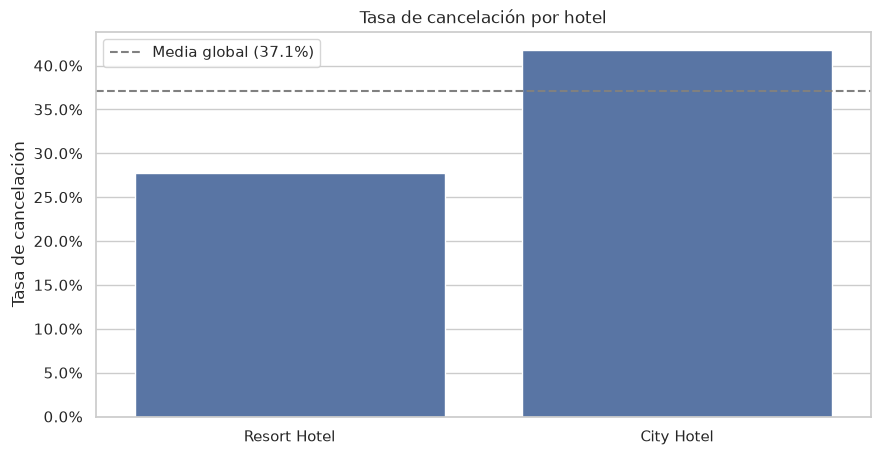

In [17]:
print(tasa_cancelacion(df_clean, "hotel"))

ax = sns.barplot(data=df_clean, x="hotel", y="is_canceled", errorbar=None)
ax.axhline(TASA_GLOBAL, ls="--", color="grey", label=f"Media global ({TASA_GLOBAL:.1%})")
ax.set(title="Tasa de cancelación por hotel", xlabel="", ylabel="Tasa de cancelación")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend()
plt.show()

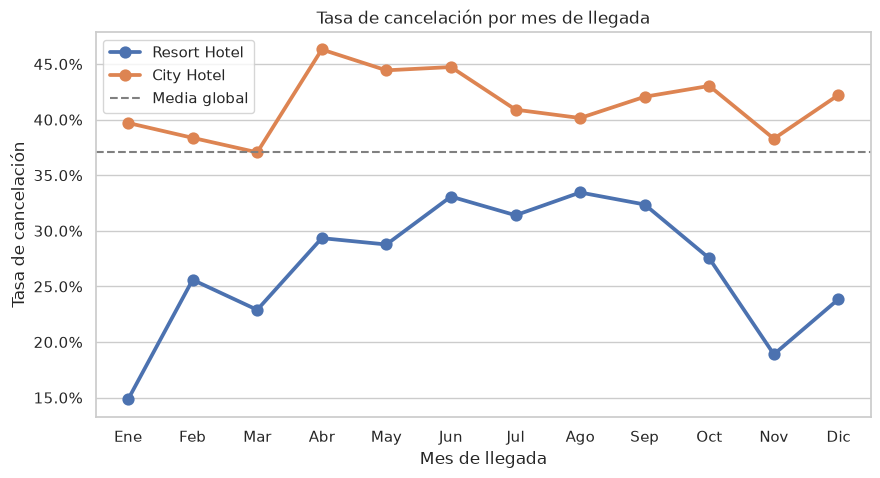

hotel,City Hotel,Resort Hotel
Ene,0.397,0.148
Feb,0.384,0.256
Mar,0.371,0.229
Abr,0.463,0.293
May,0.444,0.288
Jun,0.447,0.331
Jul,0.409,0.314
Ago,0.401,0.334
Sep,0.421,0.324
Oct,0.430,0.275


In [18]:
nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                 "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax = sns.pointplot(data=df_clean, x="arrival_month_num", y="is_canceled",
                   hue="hotel", errorbar=None)
ax.axhline(TASA_GLOBAL, ls="--", color="grey", label="Media global")
ax.set(title="Tasa de cancelación por mes de llegada", xlabel="Mes de llegada", ylabel="Tasa de cancelación")
ax.set_xticks(range(12))
ax.set_xticklabels(nombres_meses)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend()
plt.show()

# Tabla: filas = mes, columnas = hotel
(df_clean.groupby(["arrival_month_num", "hotel"])["is_canceled"]
 .mean().unstack().round(3)
 .set_axis(nombres_meses, axis=0))

                       tasa  reservas
distribution_channel                 
Undefined             0.800         5
TA/TO                 0.411     97749
Corporate             0.221      6651
GDS                   0.192       193
Direct                0.175     14610 

                 tasa  reservas
market_segment                 
Undefined       1.000         2
Groups          0.611     19790
Online TA       0.368     56408
Offline TA/TO   0.343     24181
Aviation        0.221       235
Corporate       0.188      5282
Direct          0.154     12582
Complementary   0.122       728 



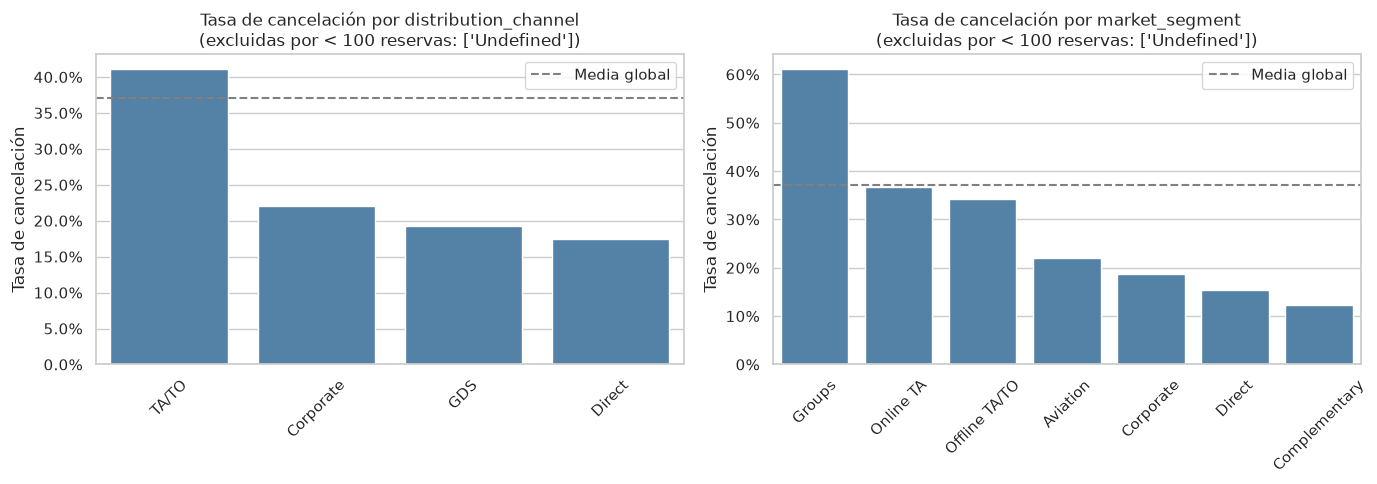

In [19]:
MIN_RESERVAS = 100 # Por debajo de este tamaño la tasa no es fiable y distorsiona el gráfico

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["distribution_channel", "market_segment"]):
    tabla = tasa_cancelacion(df_clean, col)
    print(tabla, "\n")
    
    # Solo se grafican categorías con volumen suficiente; se indica cuales se excluyen
    fiables = tabla[tabla["reservas"] >= MIN_RESERVAS]
    excluidas = tabla.index[tabla["reservas"] < MIN_RESERVAS].tolist()
     
    sns.barplot(x=fiables.index, y=fiables["tasa"], ax=ax, color="steelblue")
    ax.axhline(TASA_GLOBAL, ls="--", color="grey", label="Media global")
    ax.set(title=f"Tasa de cancelación por {col}\n(excluidas por < {MIN_RESERVAS} reservas: {excluidas})",
           xlabel="", ylabel="Tasa de cancelación")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    
plt.tight_layout()
plt.show()

In [20]:
# ¿Se mantiene la diferencia en hoteles dentro de cada segmento?
tabla_hs = (df_clean.groupby(["market_segment", "hotel"])["is_canceled"]
            .agg(["mean", "count"]).round(3)
            .unstack("hotel"))
tabla_hs[tabla_hs[("count", "City Hotel")] >= MIN_RESERVAS]

mean                   count             
hotel          City Hotel Resort Hotel City Hotel Resort Hotel
market_segment                                                
Aviation            0.221          NaN      235.0          NaN
Complementary       0.106        0.164      527.0        201.0
Corporate           0.215        0.152     2977.0       2305.0
Direct              0.174        0.135     6072.0       6510.0
Groups              0.689        0.424    13959.0       5831.0
Offline TA/TO       0.429        0.152    16711.0       7470.0
Online TA           0.375        0.352    38679.0      17729.0

### Conclusiones 4.1: hotel, mes y canal

**Hotel.** El City Hotel cancela un 41,8% frente al 27,8% del Resort. Al comparar dentro de cada segmento, la diferencia casi desaparece en el cliente individual (Online TA: 37,5% frente a 35,2%) y se concentra en grupos (68,9% frente a 42,4%) y touroperadores offline (42,9% frente a 15,2%).
→ *Acción:* priorizar la revisión de los contratos de grupos y TTOO del City Hotel (fechas de release, cláusulas de attrition, depósitos por bloque).

**Mes.** El City Hotel supera la media global todo el año (37-46%, con pico de abril a junio). El Resort es estacional: 14,8% en enero y 33,4% en agosto.
→ *Acción:* overbooking estable y más agresivo en el City Hotel. Overbooking dinámico por temporada en el Resort.

**Canal y segmento.** TA/TO concentra el 82% de las reservas y cancela un 41,1%, frente al 17,5% del canal directo. Groups es el segmento de mayor riesgo (61,1%).
→ *Acción:* impulsar la reserva directa, que cancela menos y no paga comisión. En TA/TO no se puede penalizar el canal entero por su volumen: el modelo debe permitir actuar solo sobre las reservas de riesgo.

*Nota metodológica:* el efecto del hotel depende del segmento (interacción). Esto justifica probar modelos basados en árboles, que capturan interacciones de forma automática.

In [21]:
# Descripción del lead_time
print(df_clean["lead_time"].describe().round(1), "\n")

# Mediana y media por estado de la reserva: si difieren mucho, hay asimetría
print(df_clean.groupby("is_canceled")["lead_time"].agg(["median", "mean"]).round(1))

count    119208.0
mean        104.1
std         106.9
min           0.0
25%          18.0
50%          69.0
75%         161.0
max         737.0
Name: lead_time, dtype: float64 

             median   mean
is_canceled               
0              45.0   80.1
1             113.0  144.9


            tasa  reservas
lead_time                 
0-7 días   0.096     19635
8-30       0.279     18945
31-90      0.377     29528
91-180     0.447     26420
181-365    0.555     21533
>365       0.677      3147 



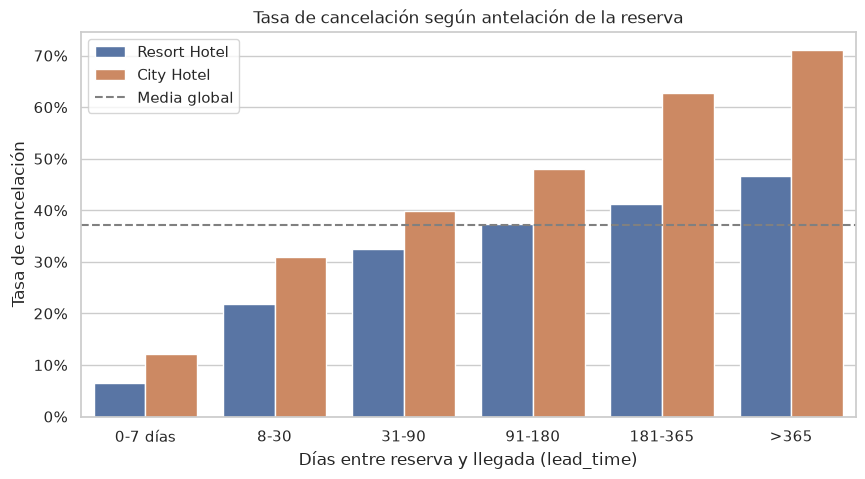

In [22]:
# Tasa de cancelación por tramos de antelación
# Tramos con significado de negocio (horizontes habituales en Revenue Management)
tramos = [-1, 7, 30, 90, 180, 365, df_clean["lead_time"].max()]
etiquetas = ["0-7 días", "8-30", "31-90", "91-180", "181-365", ">365"]
lead_tramo = pd.cut(df_clean["lead_time"], bins=tramos, labels=etiquetas)

# Tabla: tasa y volumen por tramo (global)
tabla_lt = (df_clean.groupby(lead_tramo, observed=True)["is_canceled"]
            .agg(tasa="mean", reservas="count").round(3))
print(tabla_lt, "\n")

# Gráfico por tramo y hotel
ax = sns.barplot(x=lead_tramo, y=df_clean["is_canceled"], hue=df_clean["hotel"], errorbar=None)
ax.axhline(TASA_GLOBAL, ls="--", color="grey", label="Media global")
ax.set(title="Tasa de cancelación según antelación de la reserva",
       xlabel="Días entre reserva y llegada (lead_time)", ylabel="Tasa de cancelación")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend()
plt.show()

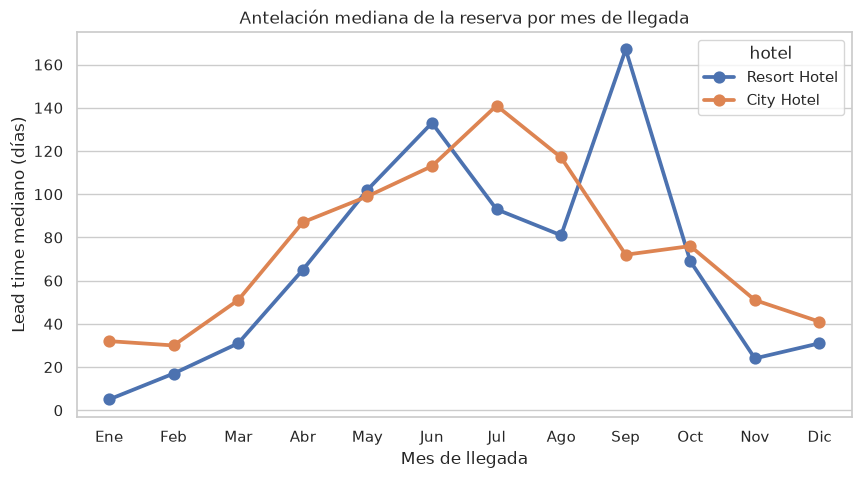

In [23]:
# ¿explica el lead_time el pico de verano del Resort?
ax = sns.pointplot(data=df_clean, x="arrival_month_num", y="lead_time",
                   hue="hotel", estimator=np.median, errorbar=None)
ax.set(title="Antelación mediana de la reserva por mes de llegada",
       xlabel="Mes de llegada", ylabel="Lead time mediano (días)")
ax.set_xticks(range(12))
ax.set_xticklabels(nombres_meses)
plt.show()

### Conclusiones 4.2: lead time

**Observado.** La reserva cancelada típica se hizo con 113 días de antelación, frente a 45 días en las no canceladas. La tasa de cancelación crece en todos los tramos: 9,6% en la última semana, más del 50% a partir de 180 días y 67,7% con más de un año. El patrón es el mismo en los dos hoteles.

**Interpretación.** A más antelación, más tiempo de exposición a cambios de planes u ofertas alternativas. La relación no es lineal: el salto más brusco se produce entre la última semana y el último mes.

**Hipótesis de estacionalidad (confirmada solo en parte).** En el Resort, la antelación y la cancelación suben juntas de invierno a verano. Sin embargo, en julio y agosto la antelación baja y la cancelación se mantiene alta: el lead time no explica toda la estacionalidad.

→ *Acción 1:* aplicar políticas de depósito o prepago a las reservas con más de 90 días de antelación, que es donde el riesgo supera la media.
→ *Acción 2:* en el forecast de ocupación, ponderar las reservas OTB por su probabilidad de cancelación según la antelación. Esto afina la política de overbooking.

*Nota:* parte del efecto del lead time puede deberse al segmento, porque los grupos reservan con más antelación y cancelan más. El modelo y SHAP permitirán separar ambos efectos.

In [24]:
# Comparación global
# Etiqueta legible del target para leyendas de gráficos (solo visualización)
estado = df_clean["is_canceled"].map({0: "No cancelada", 1: "Cancelada"})

print(df_clean.groupby(estado)["adr"].agg(["mean", "median", "count"]).round(1))

               mean  median  count
is_canceled                       
Cancelada     104.9    96.3  44198
No cancelada  100.2    92.7  75010


                  mean                 median             
is_canceled  Cancelada No cancelada Cancelada No cancelada
hotel                                                     
City Hotel       104.6        106.0      99.9        100.0
Resort Hotel     105.8         90.8      84.0         72.0


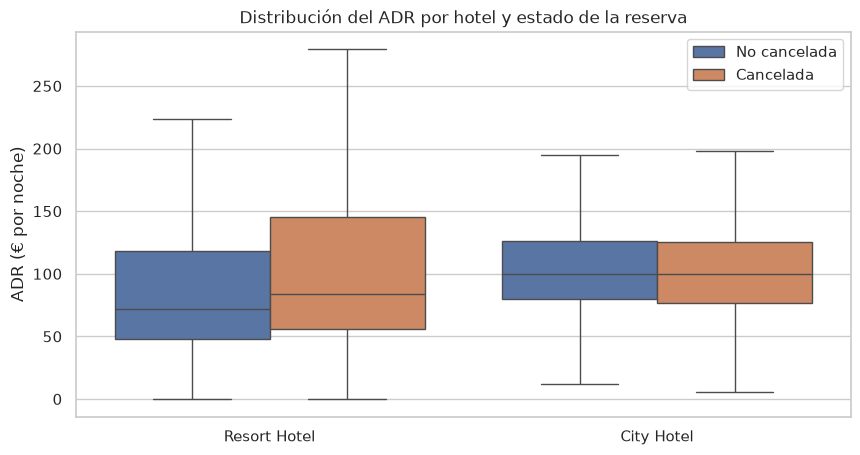

In [25]:
# Comparación por hotel
# Media y mediana del ADR por hotel y estado de la reserva
print(df_clean.groupby(["hotel", estado])["adr"]
      .agg(["mean", "median"]).round(1)
      .unstack())

ax = sns.boxplot(x=df_clean["hotel"], y=df_clean["adr"], hue=estado, showfliers=False)
ax.set(title="Distribución del ADR por hotel y estado de la reserva",
       xlabel="", ylabel="ADR (€ por noche)")
ax.legend(title="")
plt.show()

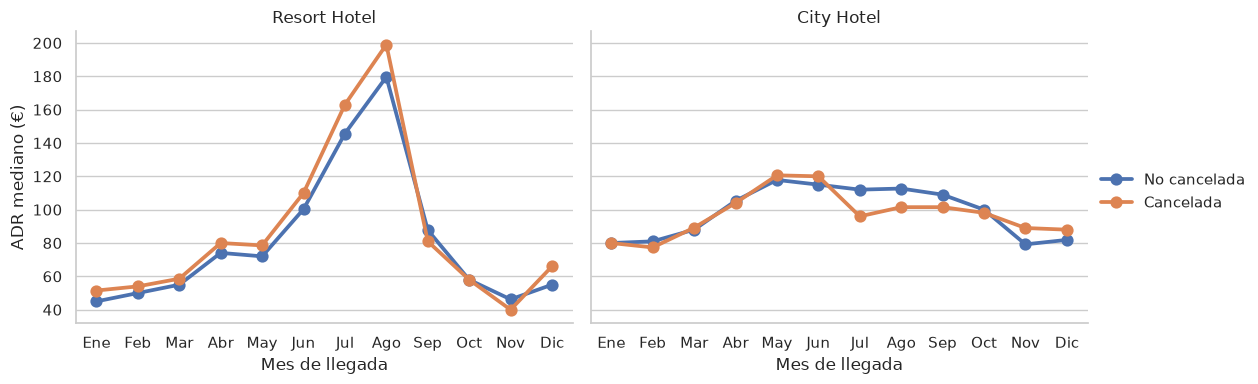

In [26]:
# Comparación por hotel y mes
g = sns.catplot(x=df_clean["arrival_month_num"], y=df_clean["adr"], hue=estado,
                col=df_clean["hotel"], kind="point", estimator=np.median,
                errorbar=None, height=4, aspect=1.4)
g.set_xticklabels(nombres_meses)
g.set_axis_labels("Mes de llegada", "ADR mediano (€)")
g.set_titles("{col_name}")
g._legend.set_title("")
plt.show()

### Conclusiones 4.3: ADR y cancelación

**Observado (global).** Las reservas canceladas tienen un ADR algo mayor: 104,9 € frente a 100,2 € de media, y 96,3 € frente a 92,7 € de mediana.

**Observado (por hotel).** La diferencia viene casi entera del Resort (mediana de 84 € en canceladas frente a 72 € en no canceladas). En el City Hotel el precio no distingue entre canceladas y no canceladas (medianas de 99,9 € frente a 100 €).

**Observado (por hotel y mes).** En el Resort, dentro del mismo mes, las canceladas son más caras en temporada alta (julio: 163 € frente a 145 €; agosto: 199 € frente a 180 €). La diferencia no se explica solo por la estacionalidad del precio.

**Interpretación e hipótesis.** El ADR es un precio por habitación, no por persona. La relación puede deberse a sensibilidad al precio (el cliente sigue buscando alternativas más baratas) o al tamaño de la reserva (familias, habitaciones grandes). El EDA no permite distinguirlas. Se creará un ADR por persona en el feature engineering.

→ *Acción:* en el Resort en temporada alta, proteger las reservas de mayor valor. Por ejemplo, con una tarifa no reembolsable con pequeño descuento (*advance purchase*), que convierte al cliente que compara precios en un cliente comprometido.
→ *Impacto:* el ingreso en riesgo se concentra en el Resort en verano, cuando cada habitación vacía cuesta más y el overbooking es más necesario.

In [27]:
# Tasa de cancelación por tipo de depósito
print(tasa_cancelacion(df_clean, "deposit_type"))

               tasa  reservas
deposit_type                 
Non Refund    0.994     14586
No Deposit    0.284    104460
Refundable    0.222       162


In [28]:
# Perfil de las reservas Non Refund frente al resto
es_nr = df_clean["deposit_type"] == "Non Refund"
es_dup = df_clean.duplicated(keep=False)

def perfil(mascara):
    """Características clave de un conjunto de reservas."""
    sub = df_clean[mascara]
    return pd.Series({
        "Reservas": len(sub),
        "% City Hotel": (sub["hotel"] == "City Hotel").mean() * 100,
        "% Groups": (sub["market_segment"] == "Groups").mean() * 100,
        "% Offline TA/TO": (sub["market_segment"] == "Offline TA/TO").mean() * 100,
        "% Portugal (PRT)": (sub["country"] == "PRT").mean() * 100,
        "% filas duplicadas": es_dup[mascara].mean() * 100,
        "% cliente repetidor": sub["is_repeated_guest"].mean() * 100,
        "Lead Time mediano (días)": sub["lead_time"].median(),
        "ADR mediano (€)": sub["adr"].median(), 
    })

pd.DataFrame({"Non Refund": perfil(es_nr), "Resto": perfil(~es_nr)}).round(1)

,Non Refund,Resto
Reservas,14586.0,104622.0
% City Hotel,88.2,63.4
% Groups,62.9,10.1
% Offline TA/TO,34.3,18.3
% Portugal (PRT),97.2,32.8
% filas duplicadas,98.1,24.7
% cliente repetidor,0.4,3.5
Lead Time mediano (días),183.0,57.0
ADR mediano (€),86.0,95.5


In [29]:
# ¿La cancelación de los Non Refund depende del segmento del hotel?

# Si la tasa es ~igual de extrema en TODOS los segmentos y hoteles,
# el patrón no depende del tipo de cliente -> más sospechoso de artefacto
print(tasa_cancelacion(df_clean[es_nr], "market_segment"), "\n")
print(tasa_cancelacion(df_clean[es_nr], "hotel"))

                 tasa  reservas
market_segment                 
Offline TA/TO   0.999      5005
Groups          0.993      9172
Online TA       0.946        56
Corporate       0.934       334
Direct          0.842        19 

               tasa  reservas
hotel                        
City Hotel    0.998     12867
Resort Hotel  0.960      1719


In [30]:
# ¿el efecto Portugal viene de este bloque?
prt = df_clean["country"] == "PRT"

print(f"Tasa global sin Non Refund: {df_clean.loc[~es_nr, 'is_canceled'].mean():.3f}")
print(f"Portugal (todas las reservas): {df_clean.loc[prt, 'is_canceled'].mean():.3f}")
print(f"Portugal sin Non Refund: {df_clean.loc[prt & ~es_nr, 'is_canceled'].mean():.3f}")
print(f"Resto de países sin Non Refund: {df_clean.loc[~prt & ~es_nr, 'is_canceled'].mean():.3f}")

Tasa global sin Non Refund: 0.284
Portugal (todas las reservas): 0.567
Portugal sin Non Refund: 0.390
Resto de países sin Non Refund: 0.232


In [31]:
# === Exclusión de deposit_type (evidencia en la sección 4.4) ===
# - Separación casi perfecta (99,4% de cacelación en Non Refund): mismo criterio que parking.
# - Contradice la acción de negocio: el modelo aprendería "depósito no reembolsable => cancela."
# Se excluye la COLUMNA, no las reservas: sus cancelaciones son datos reales.
# Se mantienen en df_clean para la prueba de sensibilidad del modelado.
df_model = df_model.drop(columns=["deposit_type"])

print(f"Columnas en df_model: {df_model.shape[1]}")

Columnas en df_model: 28


### 4.4 Tipo de depósito (análisis adicional)

**Observado.** Las reservas `Non Refund` cancelan en un 99,4% (14.586 reservas), frente al 28,4% de `No Deposit`. Es lo contrario de lo que cabría esperar de un depósito no reembolsable.

**Perfil.** Las `Non Refund` son un bloque muy homogéneo: un 97% son grupos o touroperadores, un 97% son de Portugal, un 98% son filas duplicadas, un 88% son del City Hotel, y tienen un lead time mediano de 183 días (frente a 57 del resto).

**Hipótesis (no verificables con estos datos).**
- A: bloques contratados por touroperadores que liberan las habitaciones no vendidas. Si es así, no hay ingreso perdido, porque el depósito se cobró.
- B: artefacto de registro, con el depósito asignado después de la cancelación. Sería fuga de información.

**Decisión: excluir `deposit_type` del modelo.**
1. Coherencia con el criterio del Paso 3: una separación casi perfecta indica posible fuga.
2. Contradicción de negocio: el modelo aprendería que el depósito no reembolsable aumenta el riesgo, justo la acción preventiva que el PDF propone.
3. Si la hipótesis A es cierta, estas reservas no necesitan acción preventiva: el valor del modelo está en las reservas sin depósito.

Se excluye la columna, no las reservas. Su efecto se medirá con una prueba de sensibilidad en el modelado.

**Efecto sobre `country`.** Sin el bloque `Non Refund`, Portugal pasa del 56,7% al 39,0% de cancelación, pero sigue por encima del resto de países (23,2%). Una parte de la anomalía venía del bloque y otra se mantiene. `country` se conserva con prueba de sensibilidad.

→ *Conclusión de negocio:* la población donde el modelo aporta valor son las reservas sin depósito: el 88% del volumen, con una tasa de cancelación del 28,4%.

In [32]:
# Creación de variables
df_fe = df_model.copy()

# meal: "Undefined" y "SC" significan lo mismo (sin régimen de comidas), según la documentación del Dataset
df_fe["meal"] = df_fe["meal"].replace("Undefined", "SC")

# --- Tamaño y composición de la reserva ---
df_fe["total_guests"] = df_fe["adults"] + df_fe["children"] + df_fe["babies"]               # Tamaño del grupo
df_fe["has_children"] = ((df_fe["children"] + df_fe["babies"]) > 0).astype(int)             # Reserva familiar

# --- Duración y valor económico ---
df_fe["total_nights"] = df_fe["stays_in_weekend_nights"] + df_fe["stays_in_week_nights"]    # Duración de la estancia
df_fe["adr_per_person"] = df_fe["adr"] / df_fe["total_guests"]                              # Precio real, sin efecto tamaño
df_fe["booking_value"] = df_fe["adr"] * df_fe["total_nights"]                               # Ingreso en riesgo si se cancela

# --- Tipo de intermediación ---
df_fe["has_agent"] = (df_fe["agent"] != 0).astype(int)              # Reserva a través de agencia
df_fe["has_company"] = (df_fe["company"] != 0).astype(int)          # Reserva pagada por empresa

# --- Transformaciones temporales ---
df_fe["lead_time_log"] = np.log1p(df_fe["lead_time"])               # Refleja el efecto no lineal de la antelación (4.2)
df_fe["arrival_weekday"] = df_fe["arrival_date"].dt.dayofweek       # 0 = lunes ... 6 = domingo

print(f"Columnas tras crear variables: {df_fe.shape[1]}")

Columnas tras crear variables: 37


In [33]:
cols_eliminar = [
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "adults", "children", "babies",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "agent", "company"
]
df_fe = df_fe.drop(columns=cols_eliminar)

# Comprobaciones de calidad: sin nulos ni infinitos tras los calculos
print(f"Columnas finales: {df_fe.shape[1]}")
print(f"Nulos: {df_fe.isnull().sum().sum()} | Infinitos: {np.isinf(df_fe.select_dtypes('number')).sum().sum()}")
print(df_fe.columns.tolist())

Columnas finales: 26
Nulos: 0 | Infinitos: 0
['hotel', 'is_canceled', 'lead_time', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'days_in_waiting_list', 'customer_type', 'adr', 'total_of_special_requests', 'arrival_month_num', 'arrival_date', 'total_guests', 'has_children', 'total_nights', 'adr_per_person', 'booking_value', 'has_agent', 'has_company', 'lead_time_log', 'arrival_weekday']


In [34]:
# Variables binarias nuevas: tasa de cancelación en cada grupo
for col in ["has_children", "has_agent", "has_company"]:
    print(tasa_cancelacion(df_fe, col), "\n")
    
# Variables numéricas nuevas: mediana en canceladas frente a no canceladas
print(df_fe.groupby("is_canceled")[["total_guests", "total_nights",
                                    "adr_per_person", "booking_value"]].median())

               tasa  reservas
has_children                 
0             0.373    109876
1             0.349      9332 

            tasa  reservas
has_agent                 
1          0.390    102928
0          0.247     16280 

              tasa  reservas
has_company                 
0            0.383    112440
1            0.174      6768 

             total_guests  total_nights  adr_per_person  booking_value
is_canceled                                                           
0                     2.0           3.0       49.425833         259.65
1                     2.0           3.0       49.500000         272.00


In [35]:
# ¿Se mantiene la diferencia de precio del Resort al medirla por persona?
print(df_fe.groupby(["hotel", "is_canceled"])[["adr", "adr_per_person"]]
      .median().round(1).unstack("is_canceled"))

                adr       adr_per_person      
is_canceled       0     1              0     1
hotel                                         
City Hotel    100.0  99.9           54.0  50.2
Resort Hotel   72.0  84.0           40.5  42.0


**Actualización (tras el feature engineering).** En el Resort, la diferencia de ADR entre canceladas y no canceladas (+17%) casi desaparece al medirla por persona (+4%). La mayor parte del efecto se debe al tamaño de la reserva, no al precio. La recomendación se matiza: proteger especialmente las reservas grandes o familiares del Resort en temporada alta.

## 5. Feature engineering

**Principio metodológico.** En esta sección solo se hacen transformaciones fila a fila: cada valor se calcula con los datos de su propia fila. Las transformaciones que aprenden de los datos (agrupar categorías poco frecuentes, escalar, codificar) se hacen después de la partición, dentro de un Pipeline ajustado solo con el train. Así se evita el data leakage.

| Variable | Justificación de negocio |
|---|---|
| `total_guests` | Tamaño del grupo: más personas implican más coordinación y más planes que pueden cambiar |
| `has_children` | Las familias planifican en torno a las vacaciones escolares, con un compromiso distinto |
| `total_nights` | Duración de la estancia: indica planificación y la cantidad de ingreso en juego |
| `adr_per_person` | Separa el precio real del tamaño de la reserva (pregunta abierta en la 4.3) |
| `booking_value` | Ingreso total de la reserva: lo que se pierde si se cancela. Base para el impacto económico |
| `has_agent` | Reserva intermediada frente a directa: el canal directo cancela mucho menos (4.1) |
| `has_company` | Una reserva de empresa tiene menos flexibilidad. Cancela un 17,4% frente al 38,3% |
| `lead_time_log` | Recoge la relación no lineal de la antelación (4.2) para la Regresión Logística |
| `arrival_weekday` | Distingue perfiles de viajero: ocio de fin de semana o viaje de trabajo |

**Variables eliminadas:** `arrival_date_year` (no generaliza a años futuros), columnas de fecha redundantes, los componentes de `total_guests` y `total_nights` (para evitar multicolinealidad) y los IDs `agent` y `company` (sin orden numérico, sustituidos por variables binarias).

**Corrección:** en `meal`, "Undefined" pasa a ser "SC", porque ambos significan sin régimen según la documentación del dataset.

*Las variables con poca señal individual (`has_children`, `adr_per_person`) se mantienen: pueden tener efecto en interacción con otras. SHAP permitirá valorarlo.*

In [36]:
# === Partición temporal por fecha de llegada ===
# Train: llegadas hasta 31/12/2016 | Test: llegadas desde 01/01/2017 (ene-ago 2017)
FECHA_CORTE = pd.Timestamp("2017-01-01")

# Ordenamos cronológicamente conservando el índice original (permite recuperar columnas de df_clean)
df_fe = df_fe.sort_values("arrival_date", kind="stable")

train = df_fe[df_fe["arrival_date"] < FECHA_CORTE]
test = df_fe[df_fe["arrival_date"] >= FECHA_CORTE]

# Resumen de la partición
for nombre, parte in [("Train", train), ("Test", test)]:
    print(f"{nombre}: {len(parte):,} reservas ({len(parte) / len(df_fe):.1%}) | "
          f"{parte['arrival_date'].min().date()} → {parte['arrival_date'].max().date()} | "
          f"tasa cancelación: {parte['is_canceled'].mean():.3f}")
    
# Separación de variables predictoras (X) y objetivo (y).
# arrival_date solo servía para partir: se elimina de las predictoras.
X_train = train.drop(columns=["is_canceled", "arrival_date"])
y_train = train["is_canceled"]
X_test = test.drop(columns=["is_canceled", "arrival_date"])
y_test = test["is_canceled"]

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

Train: 78,589 reservas (65.9%) | 2015-07-01 → 2016-12-31 | tasa cancelación: 0.362
Test: 40,619 reservas (34.1%) | 2017-01-01 → 2017-08-31 | tasa cancelación: 0.387

X_train: (78589, 24) | X_test: (40619, 24)


In [37]:
# Imports y definición de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)

# --- Tipos de variables ---
cat_cols = ["hotel", "meal", "country", "market_segment", "distribution_channel",
            "reserved_room_type", "customer_type",
            "arrival_month_num", "arrival_weekday"] # mes y día como categorías: efecto no lineal (4.1)

num_cols_lr = ["lead_time_log", "adr", "adr_per_person", "booking_value", "total_guests",
               "total_nights", "previous_cancellations", "previous_bookings_not_canceled",
               "days_in_waiting_list", "total_of_special_requests"] # lead_time_log en lugar de lead_time (4.2)

bin_cols = ["is_repeated_guest", "has_children", "has_agent", "has_company"]

# Comprobación: todas las columnas de X estśa clasificadas (salvo lead_time, reservada para los árboles)
sin_clasificar = set(X_train.columns) - set(cat_cols + num_cols_lr + bin_cols)
print("Columnas no usadas por la Regresión Logística:", sin_clasificar)

Columnas no usadas por la Regresión Logística: {'lead_time'}


In [38]:
# --- Preprocesado para la Regresión Logística ---
preprocesador_lr = ColumnTransformer([
    ("num", StandardScaler(), num_cols_lr),                     # Misma escala: regularización justa y coeficientes comparables
    ("cat", OneHotEncoder(min_frequency=200,                    # Categorías con < 200 reservas en train -> "infrequent"
                          handle_unknown="infrequent_if_exist", # Categorías nuevas en test -> "infrequent"
                          sparse_output=False), cat_cols),
    ("bin", "passthrough", bin_cols),                           # Binarias 0/1: sin transformar
]) # Las columnas no listadas (lead_time) se descartan

# --- Modelo baseline ---
modelo_lr = Pipeline([
    ("prep", preprocesador_lr),
    ("modelo", LogisticRegression(class_weight="balanced",      # Gestión del desbalanceo (36% canceladas)
                                  max_iter=1000,                # Iteraciones suficientes para converger
                                  random_state=RANDOM_STATE)),
])

# --- Validación cruzada temporal: siempre se entrena con el pasado y se valida con el futuro ---
tscv = TimeSeriesSplit(n_splits=5)
cv_auc = cross_val_score(modelo_lr, X_train, y_train, cv=tscv, scoring="roc_auc")

print("AUC por fold:", cv_auc.round(3))
print(f"AUC medio: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

AUC por fold: [0.89  0.851 0.872 0.848 0.849]
AUC medio: 0.862 ± 0.017


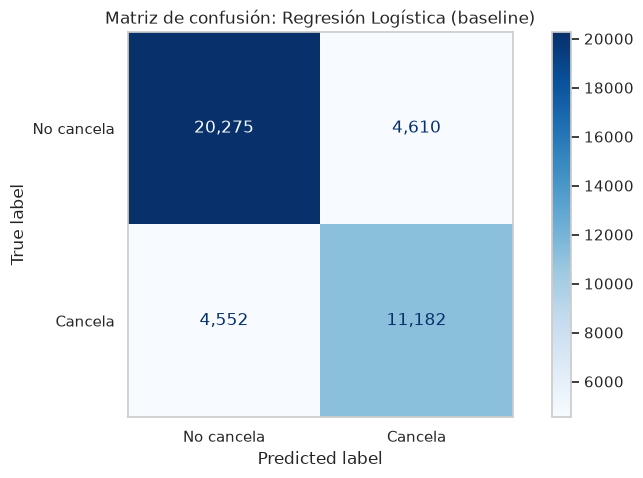

AUC train: 0.891


,AUC-ROC,Precision,Recall,F1
Modelo,,,,
Regresión Logística (baseline),0.845,0.708,0.711,0.709


In [39]:
# --- Entrenamiento con todo el train ---
modelo_lr.fit(X_train, y_train)

def evaluar(modelo, X, y, nombre, umbral=0.5):
    """Calcula las métricas del PDF y muestra la matriz de confusión."""
    proba = modelo.predict_proba(X)[:, 1]   # Probabilidad de cancelación de cada reserva
    pred = (proba >= umbral).astype(int)    # Clase final según el umbral de decisión
    
    ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=["No cancela", "Cancela"],
                                            cmap="Blues", values_format=",")
    plt.title(f"Matriz de confusión: {nombre}")
    plt.grid(False)
    plt.show()
    
    return {"Modelo": nombre,
            "AUC-ROC": roc_auc_score(y, proba),
            "Precision": precision_score(y, pred),
            "Recall": recall_score(y, pred),
            "F1": f1_score(y, pred)}
    
# Evaluación en test. Guardamos los resultados en una lista para comprar modelos al final
resultados = [evaluar(modelo_lr, X_test, y_test, "Regresión Logística (baseline)")]

# AUC en train: si es mucho mayor que en test, habría sobreajuste
auc_train = roc_auc_score(y_train, modelo_lr.predict_proba(X_train)[:, 1])
print(f"AUC train: {auc_train:.3f}")

pd.DataFrame(resultados).set_index("Modelo").round(3)

                           coeficiente  odds_ratio
previous_cancellations            2.57       13.06
country_AGO                       2.42       11.30
country_PRT                       2.04        7.72
country_CHN                       0.98        2.65
lead_time_log                     0.97        2.63
country_Unknown                   0.97        2.63
market_segment_Online TA          0.78        2.17
customer_type_Transient           0.77        2.17
country_RUS                       0.57        1.77
country_ITA                       0.45        1.58
country_NLD                      -0.68        0.50
hotel_Resort Hotel               -0.69        0.50
is_repeated_guest                -0.73        0.48
total_of_special_requests        -0.74        0.48
country_DNK                      -0.76        0.47
country_NOR                      -0.81        0.45
country_FIN                      -0.83        0.43
country_DEU                      -0.83        0.44
has_company                    

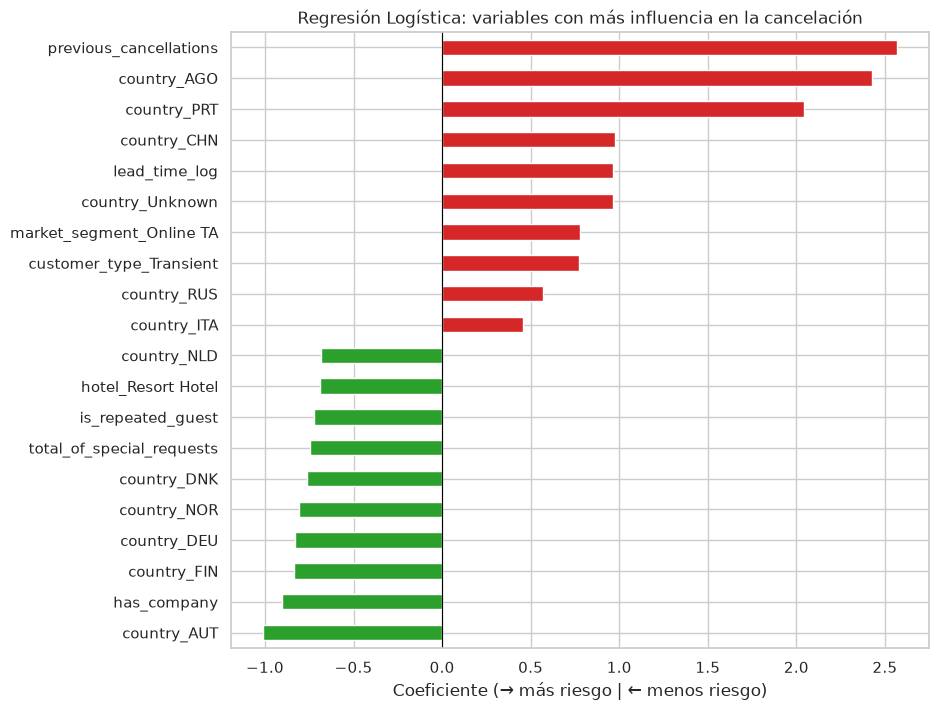

In [40]:
# Nombres de las variables tras el preprocesado (incluye cada categoría del One-Hot)
nombres = modelo_lr.named_steps["prep"].get_feature_names_out()
nombres = pd.Index(nombres).str.replace(r"^(num|cat|bin)__", "", regex=True)    # Quita el prefijo del transformador

coefs = pd.Series(modelo_lr.named_steps["modelo"].coef_[0], index=nombres)

# Las 10 variables que más aumentan el riesgo y las 10 que más lo reducen
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

tabla_coefs = pd.DataFrame({"coeficiente": top, "odds_ratio": np.exp(top)}).round(2)
print(tabla_coefs.sort_values("coeficiente", ascending=False))

# Gráfico: rojo = aumenta el riesgo, verde = lo reduce
colores = ["tab:red" if c > 0 else "tab:green" for c in top]
top.plot(kind="barh", color=colores, figsize=(9, 8))
plt.axvline(0, color="black", lw=0.8)
plt.title("Regresión Logística: variables con más influencia en la cancelación")
plt.xlabel("Coeficiente (→ más riesgo | ← menos riesgo)")
plt.show()

In [41]:
# ¿Cuantas reservas hay detrás de los países más influyentes?
paises_revisar = ["AGO", "PRT", "CHN", "Unknown", "AUT", "DEU"]
print(tasa_cancelacion(df_clean[df_clean["country"].isin(paises_revisar)], "country"))

          tasa  reservas
country                 
PRT      0.567     48482
AGO      0.566       362
CHN      0.462       999
AUT      0.182      1263
DEU      0.167      7285
Unknown  0.119       478


In [42]:
# Pruebas de sensibilidad
def crear_pipeline_lr(cat, num=num_cols_lr, binarias=bin_cols):
    """Pipeline del baseline con un conjunto de variables categóricas configurable."""
    prep = ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(min_frequency=200, handle_unknown="infrequent_if_exist",
                              sparse_output=False), cat),
        ("bin", "passthrough", binarias),
    ])
    return Pipeline([("prep", prep),
                     ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000,
                                                   random_state=RANDOM_STATE))])
    
# deposit_type se recupera de df_clean usando el índice original (solo para esta prueba)
X_train_dep = X_train.assign(deposit_type=df_clean.loc[X_train.index, "deposit_type"])
X_test_dep = X_test.assign(deposit_type=df_clean.loc[X_test.index, "deposit_type"])

escenarios = {
    "Actual (con country)": (X_train, X_test, cat_cols),
    "Sin country": (X_train, X_test, [c for c in cat_cols if c != "country"]),
    "Con deposit_type": (X_train_dep, X_test_dep, cat_cols + ["deposit_type"]),
}

filas = []
for nombre, (Xtr, Xte, cats) in escenarios.items():
    modelo = crear_pipeline_lr(cats)
    auc_cv = cross_val_score(modelo, Xtr, y_train, cv=tscv, scoring="roc_auc").mean()
    modelo.fit(Xtr, y_train)
    proba = modelo.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    filas.append({"Escenario": nombre, "AUC CV": auc_cv, "AUC test": roc_auc_score(y_test, proba),
                  "Precision": precision_score(y_test, pred), "Recall": recall_score(y_test, pred),
                  "F1": f1_score(y_test, pred)})
    
pd.DataFrame(filas).set_index("Escenario").round(3)

,AUC CV,AUC test,Precision,Recall,F1
Escenario,,,,,
Actual (con country),0.862,0.845,0.708,0.711,0.709
Sin country,0.806,0.800,0.606,0.737,0.665
Con deposit_type,0.867,0.850,0.719,0.683,0.701


### Pruebas de sensibilidad
| Escenario | AUC test | F1 |
|---|---|---|
| Con country (elegido) | 0,845 | 0,709 |
| Sin country | 0,800 | 0,665 |
| Con deposit_type | 0,844 | 0,708 |

- Quitar `country` reduce el AUC en 0,045. Se mantiene porque aporta señal real y el PDF la incluye como variable principal.
- Añadir `deposit_type` no mejora el modelo: `country` ya identifica el bloque Non Refund (efecto proxy).
- **Limitación:** usar la nacionalidad para aplicar condiciones distintas a los clientes puede tener implicaciones legales y reputacionales. En producción debería valorarse la versión sin `country`.

In [43]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

# Árboles: lead_time original (cortan por umbrales, no necesitan log) y sin escalado
num_cols_arb = ["lead_time"] + [c for c in num_cols_lr if c != "lead_time_log"]

prep_arboles = ColumnTransformer([
    ("num", "passthrough", num_cols_arb),                   # Sin escalar: los árboles no dependen de la escala
    ("cat", OneHotEncoder(min_frequency=200, handle_unknown="infrequent_if_exist",
                          sparse_output=False), cat_cols),  # Mismo tratamiento que el baseline: comparación justa
    ("bin", "passthrough", bin_cols),
])

modelo_lgbm = Pipeline([
    ("prep", prep_arboles),
    ("modelo", LGBMClassifier(class_weight="balanced",      # Misma gestión del desbalanceo que el baseline
                              subsample_freq=1,             # Activa el submuestreo de filas (subsample)
                              random_state=RANDOM_STATE, n_jobs=1, verbose=-1)),
])

# Espacio de búsqueda: controla complejidad (num_leaves, max_depth, min_child_samples)
# y regularización (subsample, colsample_bytree, reg_lambda) para evitar overfitting
param_dist = {
    "modelo__n_estimators": [200, 400, 600],
    "modelo__learning_rate": [0.03, 0.05, 0.1],
    "modelo__num_leaves": [15, 31, 63],
    "modelo__max_depth": [-1, 6, 10],
    "modelo__min_child_samples": [20, 50, 100],
    "modelo__subsample": [0.7, 0.85, 1.0],
    "modelo__colsample_bytree": [0.6, 0.8, 1.0],
    "modelo__reg_lambda": [0, 1, 5,]
}

# RandomizedSearch: 30 combinaciones al azar en lugar de las 6.561 posibles (GridSearch sería inviable)
busqueda = RandomizedSearchCV(modelo_lgbm, param_dist, n_iter=30, cv=tscv, scoring="roc_auc",
                              random_state=RANDOM_STATE, n_jobs=1, verbose=1)
busqueda.fit(X_train, y_train)

mejor_lgbm = busqueda.best_estimator_   # Reentrenado automáticamente con todo el train

print("Mejores hiperparámetros:", {k.replace("modelo__", ""): v for k, v in busqueda.best_params_.items()})
print(f"AUC CV LightGBM: {busqueda.best_score_:.3f} (baseline: {cv_auc.mean():.3f})")
print(f"AUC train: {roc_auc_score(y_train, mejor_lgbm.predict_proba(X_train)[:, 1]):.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 1, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
AUC CV LightGBM: 0.876 (baseline: 0.862)
AUC train: 0.942


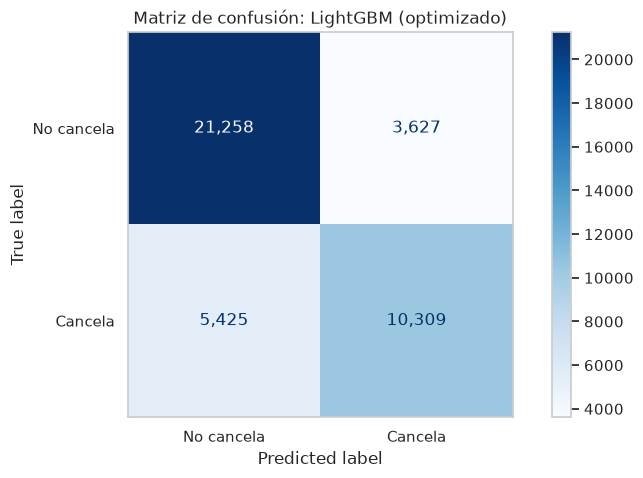

,AUC-ROC,Precision,Recall,F1
Modelo,,,,
Regresión Logística (baseline),0.845,0.708,0.711,0.709
LightGBM (optimizado),0.858,0.740,0.655,0.695


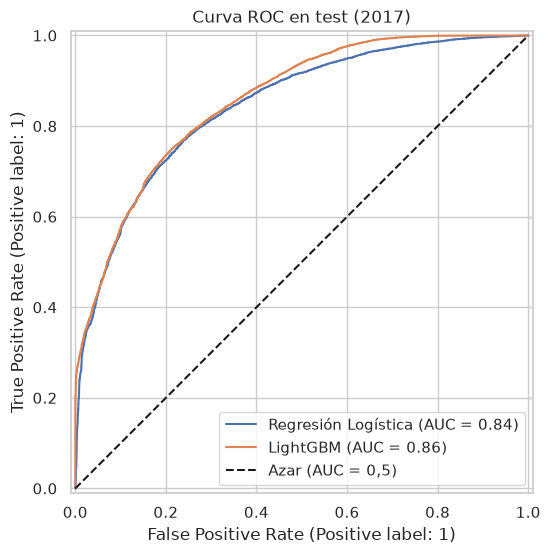

In [44]:
from sklearn.metrics import RocCurveDisplay

# Se reconstruye la lista para que re-ejecutar la celda no duplique filas
resultados = [resultados[0], evaluar(mejor_lgbm, X_test, y_test, "LightGBM (optimizado)")]
display(pd.DataFrame(resultados).set_index("Modelo").round(3))

# Curvas ROC: cuanto más arriba a la izquierda, mejor ordena el modelo las reservas por riesgo
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(modelo_lr, X_test, y_test, name="Regresión Logística", ax=ax)
RocCurveDisplay.from_estimator(mejor_lgbm, X_test, y_test, name="LightGBM", ax=ax)
ax.plot([0,1], [0,1], "k--", label="Azar (AUC = 0,5)")
ax.set_title("Curva ROC en test (2017)")
ax.legend()
plt.show()

Coste FN: 327 € | Coste FP: 98 €


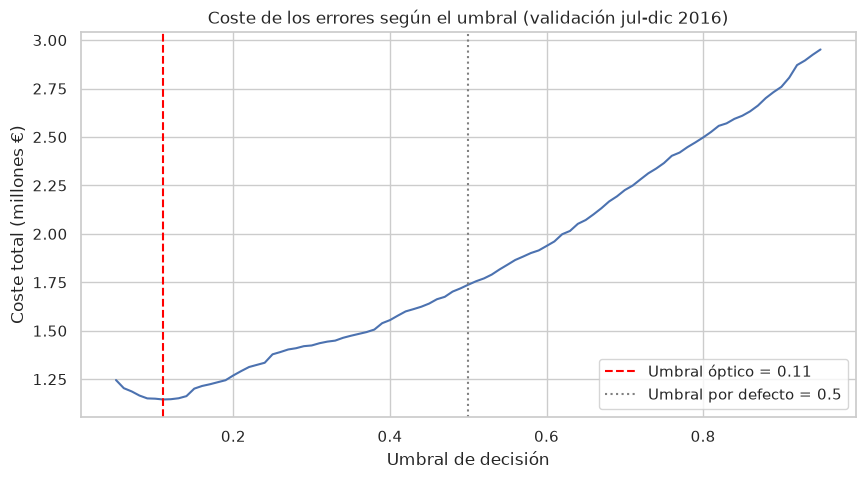

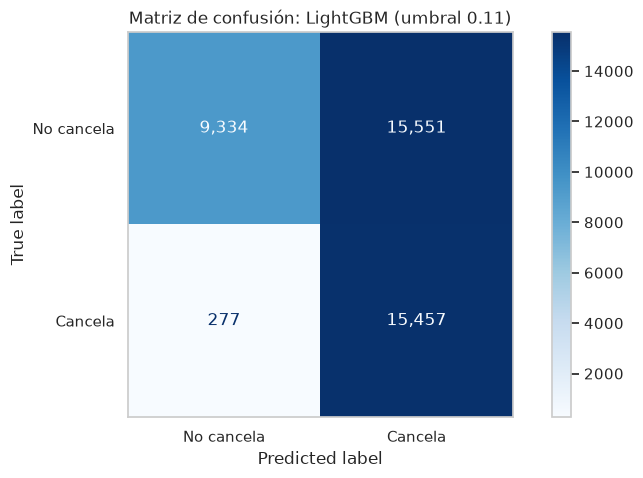

,AUC-ROC,Precision,Recall,F1
Modelo,,,,
Regresión Logística (baseline),0.845,0.708,0.711,0.709
LightGBM (optimizado),0.858,0.740,0.655,0.695
LightGBM (umbral 0.11),0.858,0.498,0.982,0.661


Sin modelo              5.14
LightGBM umbral 0,5     2.13
LightGBM umbral 0.11    1.61
Name: Coste (millones €), dtype: float64


In [45]:
from sklearn.base import clone

# --- Supuestos de coste (explícitos: se pueden ajustar con datos reales del hotel) ---
COSTE_FN = train["booking_value"].mean()    # Cancelación no detectada: se pierde el ingreso de la reserva
COSTE_FP = 0.30 * COSTE_FN                  # Acción innecesaria: descuento/upgrade + molestia al cliente (supuesto)
print(f"Coste FN: {COSTE_FN:.0f} € | Coste FP: {COSTE_FP:.0f} €")

def coste_total(proba, y, umbral):
    """Coste en € de los errores del modelo para un umbral dado."""
    pred = (proba >= umbral).astype(int)
    y = np.asarray(y)
    fn = ((pred == 0) & (y == 1)).sum()
    fp = ((pred == 1) & (y == 0)).sum()
    return fn * COSTE_FN + fp * COSTE_FP

# --- Validación temporal para elegir el umbral: entrena hasta jun-2016, valida jul-dic 2016 ---
es_val = (train["arrival_date"] >= pd.Timestamp("2016-07-01")).values
modelo_val = clone(mejor_lgbm).fit(X_train[~es_val], y_train[~es_val])
proba_val = modelo_val.predict_proba(X_train[es_val])[:, 1]
y_val = y_train[es_val]

umbrales = np.arange(0.05, 0.96, 0.01)
costes_val = [coste_total(proba_val, y_val, u) for u in umbrales]
UMBRAL_OPTIMO = umbrales[np.argmin(costes_val)]

plt.plot(umbrales, np.array(costes_val) / 1e6)
plt.axvline(UMBRAL_OPTIMO, ls="--", color="red", label=f"Umbral óptico = {UMBRAL_OPTIMO:.2f}")
plt.axvline(0.5, ls=":", color="grey", label="Umbral por defecto = 0.5")
plt.title("Coste de los errores según el umbral (validación jul-dic 2016)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Coste total (millones €)")
plt.legend()
plt.show()

# --- Evalueación en test con el umbral óptimo ---
resultados.append(evaluar(mejor_lgbm, X_test, y_test,
                          f"LightGBM (umbral {UMBRAL_OPTIMO:.2f})", umbral=UMBRAL_OPTIMO))
display(pd.DataFrame(resultados).set_index("Modelo").round(3))

# --- Impacto económico en test (2017) ---
proba_test = mejor_lgbm.predict_proba(X_test)[:, 1]
sin_modelo = y_test.sum() * COSTE_FN            # Sin modelo, todas las cancelaciones llegan sorpresa
impacto = pd.Series({
    "Sin modelo": sin_modelo,
    "LightGBM umbral 0,5": coste_total(proba_test, y_test, 0.5),
    f"LightGBM umbral {UMBRAL_OPTIMO:.2f}": coste_total(proba_test, y_test, UMBRAL_OPTIMO)
})
print((impacto / 1e6).round(2).rename("Coste (millones €)"))


/home/josele/Documentos/projects/proyecto_ml/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


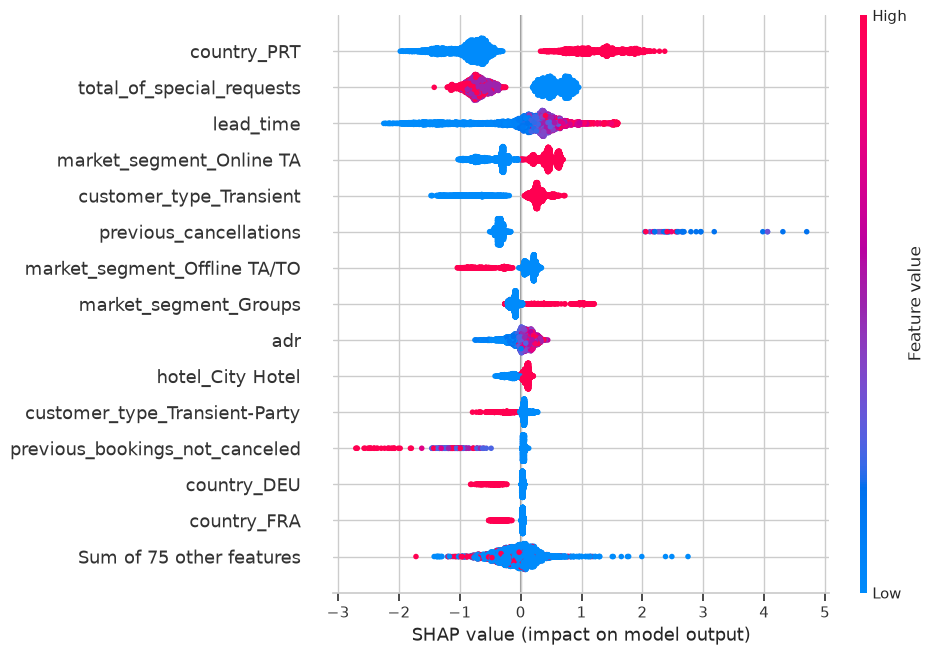

In [46]:
import shap

# Componentes entrenados del Pipeline
prep_fit = mejor_lgbm.named_steps["prep"]
lgbm_fit = mejor_lgbm.named_steps["modelo"]
nombres_arb = pd.Index(prep_fit.get_feature_names_out()).str.replace(r"^(num|cat|bin)__", "", regex=True)

# Datos de test ya transformados, con nombres legibles
X_test_prep = pd.DataFrame(prep_fit.transform(X_test), columns=nombres_arb, index=X_test.index)
X_shap = X_test_prep.sample(5000, random_state=RANDOM_STATE)    # Muestra: SHAP es costoso en 40.000 filas

explainer = shap.TreeExplainer(lgbm_fit)        # Explicador exacto y rápido para modelos de árboles
sv = explainer(X_shap)
if sv.values.ndim == 3:                         # Según la versión de SHAP puede devolver ambas cosas
    sv = sv[:, :, 1]
    
# Cada punto es una reserva. Rojo = valor alto de la variable. A la derecha = empuja hacia cancelar
shap.plots.beeswarm(sv, max_display=15)


RESERVA DE ALTO RIESGO (cancelada) | Probabilidad de cancelación: 99.6%
hotel                        Resort Hotel
lead_time                             471
country                               PRT
market_segment                     Groups
customer_type                   Transient
adr                                  47.0
total_guests                            2
total_nights                            7
total_of_special_requests               0
previous_cancellations                  0
is_repeated_guest                       0


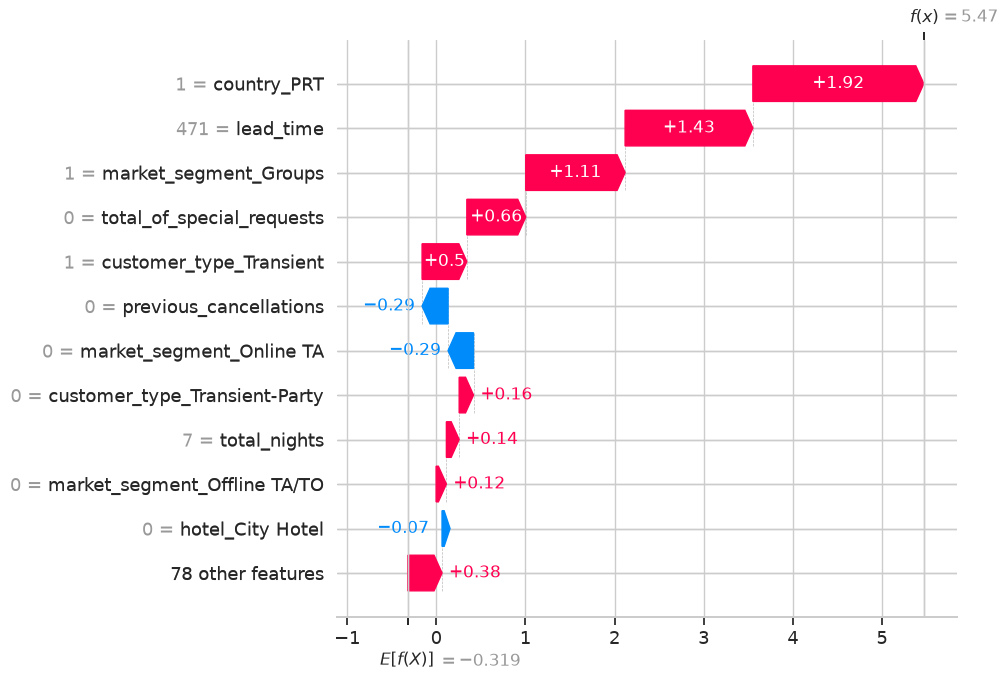


RESERVA DE BAJO RIESGO (no cancelada) | Probabilidad de cancelación: 0.2%
hotel                         Resort Hotel
lead_time                              166
country                                GBR
market_segment               Offline TA/TO
customer_type                        Group
adr                                   68.4
total_guests                             2
total_nights                             7
total_of_special_requests                3
previous_cancellations                   0
is_repeated_guest                        1


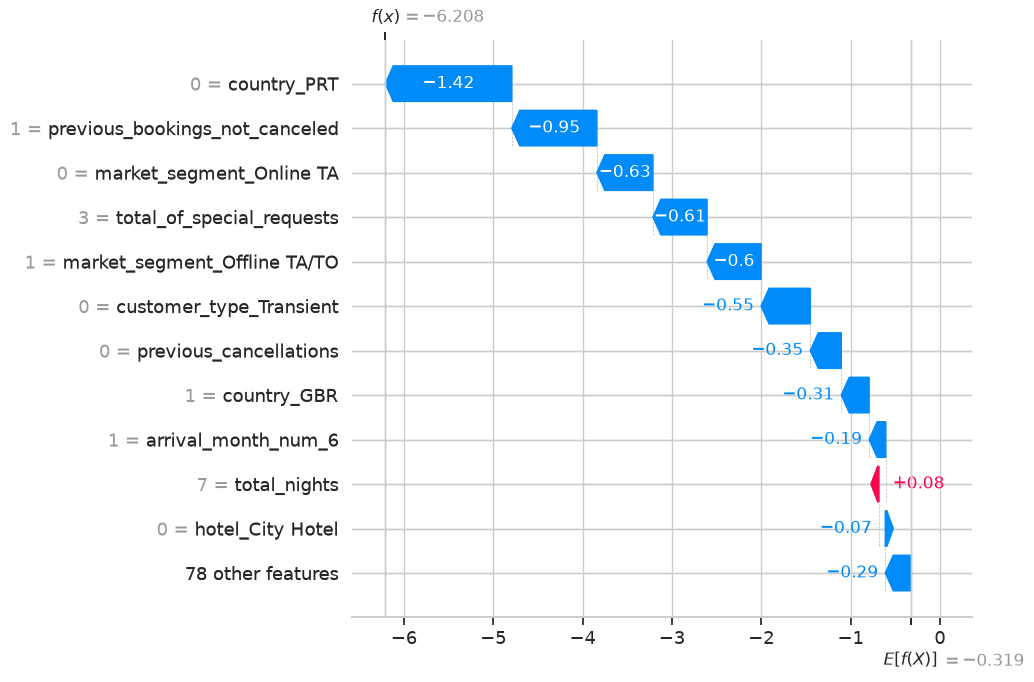

In [47]:
proba_shap = mejor_lgbm.predict_proba(X_test.loc[X_shap.index])[:, 1]
y_shap = y_test.loc[X_shap.index].values

# Posiciones dentro de la muestra
i_alto = np.where(y_shap == 1)[0][np.argmax(proba_shap[y_shap == 1])]   # Cancelada con más riesgo
i_bajo = np.where(y_shap == 0)[0][np.argmin(proba_shap[y_shap == 0])]   # No cancelada con menos riesgo

cols_ver = ["hotel", "lead_time", "country", "market_segment", "customer_type", "adr",
            "total_guests", "total_nights", "total_of_special_requests",
            "previous_cancellations", "is_repeated_guest"]

for i, titulo, in [(i_alto, "RESERVA DE ALTO RIESGO (cancelada)"),
                   (i_bajo, "RESERVA DE BAJO RIESGO (no cancelada)")]:
    print(f"\n{titulo} | Probabilidad de cancelación: {proba_shap[i]:.1%}")
    print(X_test.loc[X_shap.index[i], cols_ver].to_string())
    shap.plots.waterfall(sv[i], max_display=12) # Valores en log-odds: rojo sube el riesgo, azul lo baja

In [48]:
alto_riesgo = proba_test >= np.quantile(proba_test, 0.8)    # Top 20% de probabilidad de cancelación

def perfil_riesgo(m):
    sub = X_test[m]
    return pd.Series({
        "Reservas": m.sum(),
        "Tasa real de cancelación (%)": y_test[m].mean() * 100,
        "Lead time mediano (días)": sub["lead_time"].median(),
        "% City Hotel": (sub["hotel"] == "City Hotel").mean() * 100,
        "% Portugal": (sub["country"] == "PRT").mean() * 100,
        "% Groups": (sub["market_segment"] == "Groups").mean() * 100,
        "% Online TA": (sub["market_segment"] == "Online TA").mean() * 100,
        "% con peticiones especiales": (sub["total_of_special_requests"] > 0).mean() * 100,
        "% con cancelaciones previas": (sub["previous_cancellations"] > 0).mean() * 100,
        "% cliente repetidor": sub["is_repeated_guest"].mean() * 100,
    })
    
pd.DataFrame({"Top 20% riesgo": perfil_riesgo(alto_riesgo),
              "Resto": perfil_riesgo(~alto_riesgo)}).round(1)

,Top 20% riesgo,Resto
Reservas,8124.0,32495.0
Tasa real de cancelación (%),84.3,27.3
Lead time mediano (días),143.0,60.0
% City Hotel,89.0,62.2
% Portugal,59.4,24.9
% Groups,35.9,9.0
% Online TA,47.3,57.8
% con peticiones especiales,1.7,58.9
% con cancelaciones previas,0.3,0.8
% cliente repetidor,0.3,4.1


# 11. Conclusiones

## Modelo
| Modelo | AUC-ROC | Precision | Recall | F1 |
|---|---|---|---|---|
| Regresión Logística (baseline) | 0,845 | 0,708 | 0,711 | 0,709 |
| **LightGBM optimizado (umbral 0,5)** | **0,854** | **0,738** | 0,665 | 0,700 |
| LightGBM (umbral de coste 0,19) | 0,854 | 0,531 | 0,957 | 0,683 |

- **Modelo elegido: LightGBM.** Supera al baseline en validación temporal (AUC 0,875 frente a 0,862) y en test (0,854 frente a 0,845). Capta interacciones que la Regresión Logística no ve (hotel × segmento, precio × temporada). La mejora es moderada: la Regresión Logística sigue siendo una alternativa válida si se prioriza la simplicidad.
- **Validación realista:** partición temporal (train 2015-2016, test 2017). La ligera caída del rendimiento en test se explica en parte por la deriva de los datos: en 2017 se cancela 2,5 puntos más.
- **Lectura de negocio (umbral 0,5):** de cada 10 reservas marcadas como riesgo, unas 7 cancelan. El modelo detecta 2 de cada 3 cancelaciones.

## Perfil de reserva de alto riesgo
El 20% de reservas con mayor riesgo cancela en un **83,7%**, frente al 27,5% del resto. Su perfil:
- **Sin peticiones especiales** (solo el 1,3% tiene alguna, frente al 59% del resto): es el principal indicador de un cliente poco comprometido.
- **Mucha antelación:** lead time mediano de 143 días frente a 60.
- **City Hotel** (89%), **Portugal** (60%) y **grupos** (35,5% frente a 9,1%).
- Según SHAP, también aumentan el riesgo: agencia online, cliente *Transient* y cancelaciones previas. Lo reducen un historial de reservas no canceladas, las peticiones especiales y la reserva de empresa.

Ejemplos (waterfall): una reserva de grupo portuguesa, con 566 días de antelación y sin peticiones, tiene un 98,9% de probabilidad de cancelar. Una reserva alemana con una petición especial tiene un 1,2%, a pesar de tener 352 días de antelación: el modelo no depende solo del lead time.

## Recomendaciones para Revenue Management
1. **El umbral depende de la acción** (los falsos positivos no cuestan lo mismo en todas):
   - *Overbooking:* umbral bajo (~0,2). No afecta al cliente, así que conviene maximizar la detección.
   - *Depósito no reembolsable o contacto proactivo:* umbral alto (~0,7-0,8). Solo sobre reservas de riesgo muy alto, para no molestar a clientes fiables.
2. **Forecast de ocupación:** ponderar las reservas en cartera (OTB) por su probabilidad de cancelación en lugar de tratarlas todas como firmes.
3. **Grupos y touroperadores del City Hotel:** revisar contratos (fechas de release, cláusulas de attrition), porque concentran el riesgo.
4. **Impulsar la reserva directa y las peticiones especiales:** el cliente que interactúa con el hotel cancela mucho menos.

## Impacto económico (ilustrativo)
Con supuestos de coste de 327 € por cancelación no detectada y 98 € por acción innecesaria, el coste de los errores en 2017 pasaría de 5,14 M€ sin modelo a 2,09 M€ (umbral 0,5) y a 1,52 M€ (umbral 0,19). **Son cifras orientativas:** dependen de los supuestos y asumen que la acción preventiva evita toda la pérdida.

## Limitaciones
- **`country`:** es la variable más influyente. Aporta señal real (sin ella el AUC baja a 0,800), pero puede actuar como proxy del bloque de grupos *Non Refund*. Además, usar la nacionalidad para aplicar condiciones distintas tiene implicaciones legales y reputacionales.
- **Variables excluidas por fuga:** `reservation_status`, `reservation_status_date`, `assigned_room_type`, `booking_changes`, `required_car_parking_spaces` y `deposit_type`.
- **`total_of_special_requests`:** parte de las peticiones podría añadirse después de reservar.
- **Duplicados:** se interpretaron como bloques de grupo. Sin un ID de reserva no se puede confirmar.
- **Deriva temporal:** el modelo debe reentrenarse periódicamente.

## Próximos pasos
- Segmentar las reservas en niveles de riesgo con una acción asociada a cada nivel.
- Obtener del PMS la política de cancelación, la fecha de reserva y el ID de reserva, para confirmar las hipótesis sobre duplicados y `Non Refund`.
- Evaluar en producción una versión sin `country`.
- Reentrenar el modelo de forma periódica y monitorizar la deriva.